# Implementing Linear Regression From First Principles
Data sourced from https://www.kaggle.com/datasets/prokshitha/home-value-insights/data?select=house_price_regression_dataset.csv

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [48]:
raw = pd.read_csv('house_price_regression_dataset.csv')
raw.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


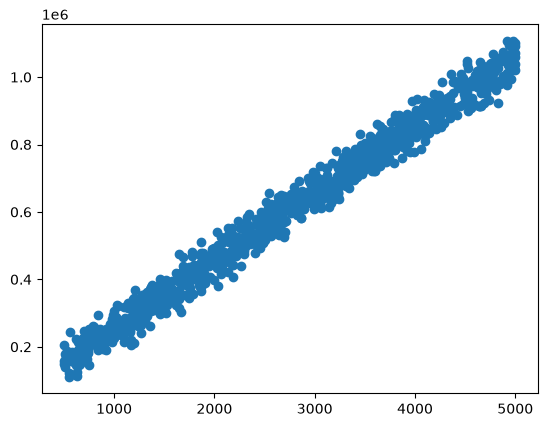

In [49]:
plt.plot(raw['Square_Footage'], raw['House_Price'], 'o');

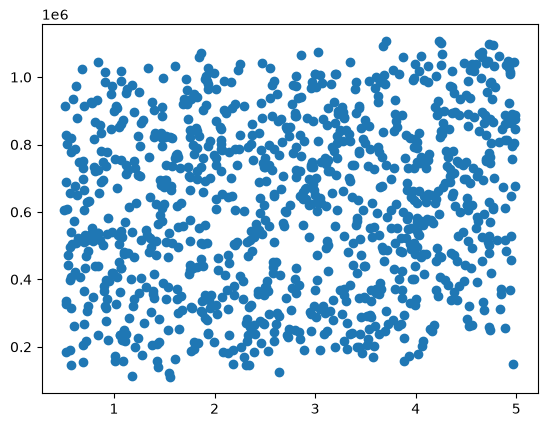

In [50]:
plt.plot(raw['Lot_Size'], raw['House_Price'], 'o');

From the plots we suspect the size of the house to be linearly related to the price

In [51]:
raw.dropna(inplace=True)  # Drop rows with missing values
# Split the data into training and testing sets
train = raw.iloc[:int(0.8*len(raw))]
test = raw.iloc[int(0.8*len(raw)):]
xtrain = train['Square_Footage'].values
ytrain = train['House_Price'].values
xtest = test['Square_Footage'].values
ytest = test['House_Price'].values

In [76]:
# Implement the cost function under the assumption of the form y = wx + b
# Assume an initial estimate of b = 0 and w = 1e6/4800 ~ 208
def J(w=208, b=0, x=xtrain, y=ytrain):
    n = len(x)
    mse = np.sum((w*x + b - y) ** 2) / (2*n)
    return mse

In [75]:
# The cost from the initial estimate is
J()

np.float64(1189715175.9263587)

In [68]:
# For gradient descent, we find the partial derivatives of the cost function with respect to w and b
def dJ_dw(w=208, b=0, x=xtrain, y=ytrain):
    n = len(x)
    return np.sum((w*x + b - y) * x) / n

def dJ_db(w=208, b=0, x=xtrain, y=ytrain):
    n = len(x)
    return np.sum(w*x + b - y) / n

# Fix the learning rate and number of iterations
alpha = 0.0000001
num_iterations = 100000

In [69]:
# Find the optimal values of w and b using gradient descent
w = 208
b = 0
for i in range(num_iterations):
    temp_w = w - alpha * dJ_dw(w, b, xtrain, ytrain)
    temp_b = b - alpha * dJ_db(w, b, xtrain, ytrain)
    w = temp_w
    b = temp_b
w, b

(np.float64(216.58587375827472), np.float64(95.49856609335048))

In [70]:
# Find the cost of the model on the training data with the optimal values of w and b
J(w, b, xtrain, ytrain)

np.float64(839934061.3318459)

In [71]:
# Compare the predicted values with the actual values on the test set
J(208, 0, xtest, ytest), J(w, b, xtest, ytest)

(np.float64(1039423565.7029854), np.float64(693537120.7348022))

Text(0.5, 1.0, 'Residuals')

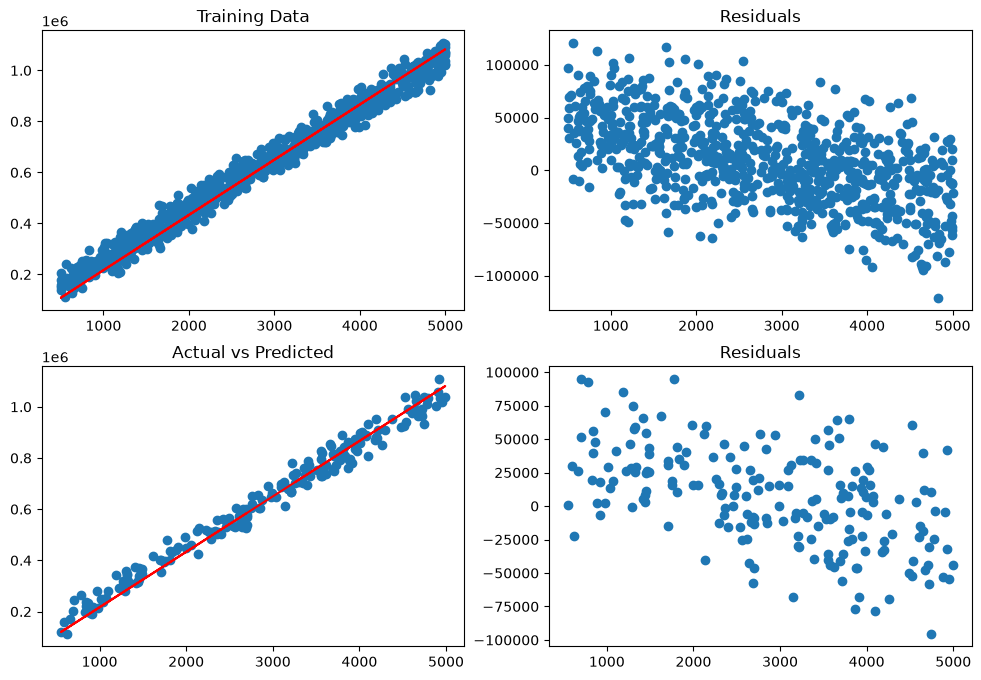

In [72]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax1.plot(xtrain, ytrain, 'o', label='Training Data')
ax1.plot(xtrain, w*xtrain + b, 'r', label='Fitted Line')
ax2.plot(xtrain, ytrain - (w*xtrain + b), 'o', label='Residuals')
ax3.plot(xtest, ytest, 'o', label='Actual')
ax3.plot(xtest, w*xtest + b, 'r', label='Predicted')
ax4.plot(xtest, ytest - (w*xtest + b), 'o', label='Residuals')
ax1.set_title('Training Data')
ax2.set_title('Residuals')
ax3.set_title('Actual vs Predicted')
ax4.set_title('Residuals')

We see that the residuals do not appear to be randomly distributed around 0, meaning a possibility that the data is not suitable for a linear model or the training was not precise enough.